# Assignment


## Brief


Write the SQL statements for the following questions.


## Instructions


Paste the answer as SQL in the answer code section below each question.


### Question 1


Let's revisit our `austin_bikeshare_demo` dbt project. Modify the `dim_station.sql` model to include the following columns:

- `avg_duration` (Average of trip durations for trips starting from each station in seconds.)

Then, rebuild the models with the following command to see if the changes are correct:

```bash
dbt run
```


**Answer:**

Paste the `dim_station.sql` model here:

```sql
WITH station_base AS (
    SELECT
        station_id,
        name AS station_name,
        status,
        address,
    FROM {{ source('austin_bikeshare', 'bikeshare_stations') }}
),

trip_starts AS (
    SELECT
        CAST(start_station_id AS INT64) AS station_id,
        AVG(duration_minutes * 60) AS avg_duration
    FROM {{ source('austin_bikeshare', 'bikeshare_trips') }}
    WHERE start_station_id IS NOT NULL
    GROUP BY start_station_id
)

SELECT
    sb.station_id,
    sb.station_name,
    sb.status,
    sb.address,
    ts.avg_duration
FROM station_base sb
LEFT JOIN trip_starts ts
    ON sb.station_id = ts.station_id
ORDER BY avg_duration DESC
```

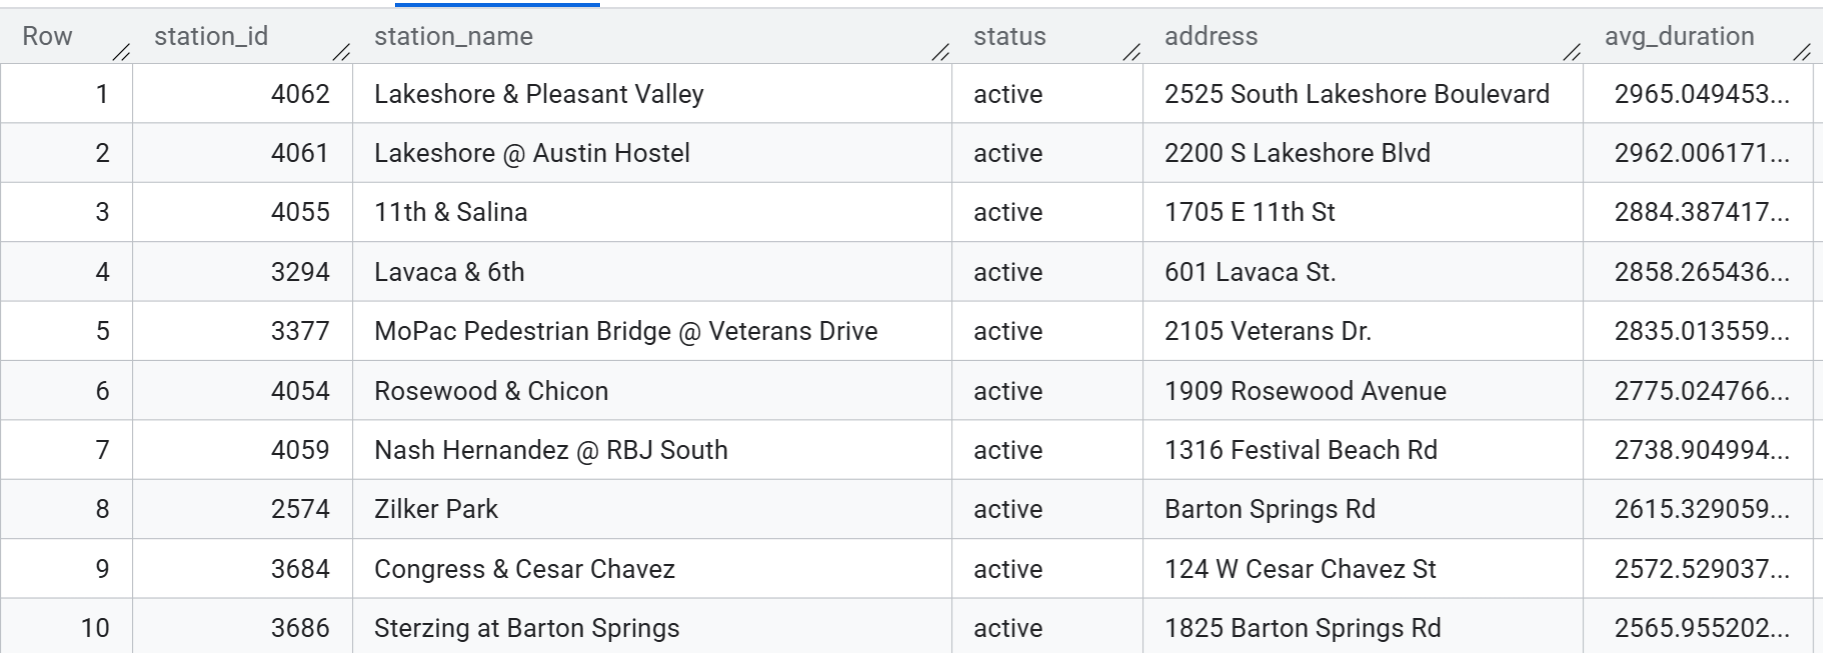
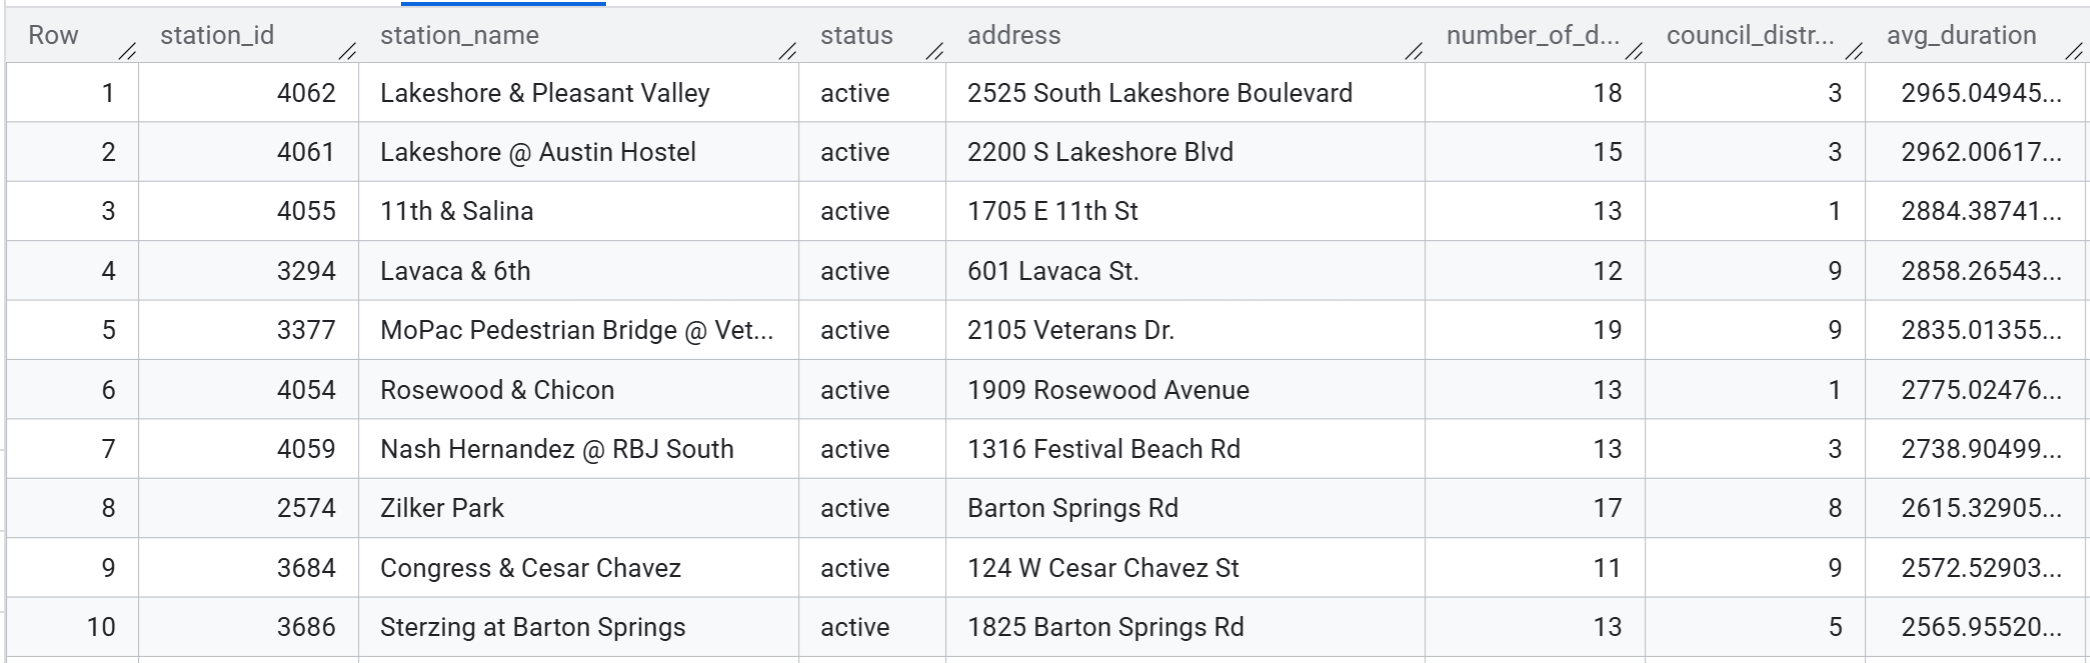